01 EDA SKIN BURN

In [1]:
# ## Dataset Overview
# - Approximately 1300 web-scraped images of skin burns
# - YOLO format labels (0=1st degree, 1=2nd degree, 2=3rd degree)
# - Mixed file types (.jpg, .jpeg, .txt annotations)
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
import random

#Visualization Settings
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_style('whitegrid')
plt.rcParams['image.cmap'] = 'viridis'

In [2]:
# ## Dataset Structure Analysis
dataset_path = 'kaggle-thermal-burn-dataset/'
class_names = {
    0: '1st_degree',
    1: '2nd_degree',
    2: '3rd_degree'
}

# Analyze file distribution
image_files = [f for f in os.listdir(dataset_path) if f.endswith(('.jpg', '.jpeg'))]
label_files = [f for f in os.listdir(dataset_path) if f.endswith('.txt')]

print(f"Total images: {len(image_files)}")
print(f"Total labels: {len(label_files)}")
print(f"Missing images: {len(label_files) - len(image_files)}")
print(f"Missing labels: {len(image_files) - len(label_files)}")

Total images: 1227
Total labels: 1441
Missing images: 214
Missing labels: -214


In [3]:
# ## Class Distribution Analysis

# Parse YOLO labels to get class distribution
class_counts = {0: 0, 1: 0, 2: 0}

for label_file in label_files[:1000]:
    try:
        with open(os.path.join(dataset_path, label_file), 'r') as f:
            for line in f:
                class_id = int(line.strip().split()[0])
                if class_id in class_counts:
                    class_counts[class_id] += 1
    except Exception as e:
        print(f"Error processing {label_file}: {e}")


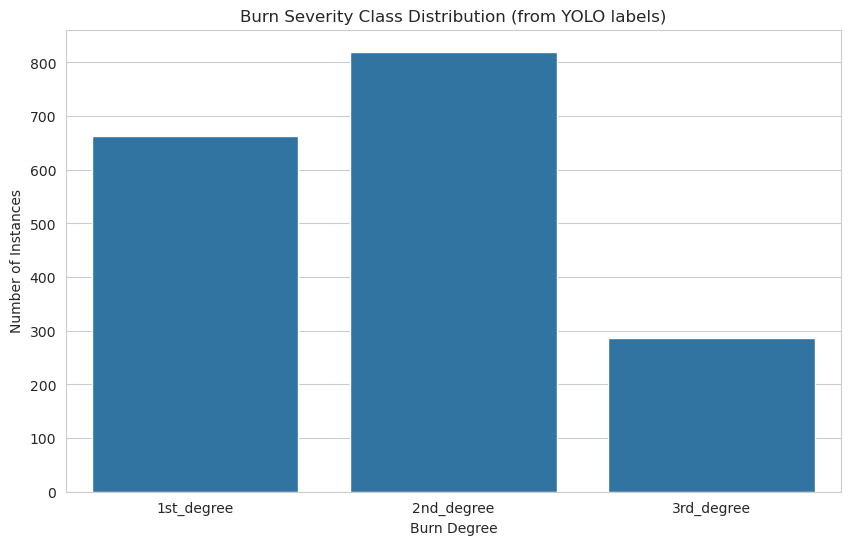

In [4]:
# Visualize class distribution
plt.figure(figsize=(10, 6))
sns.barplot(x=[class_names[k] for k in class_counts.keys()],
            y=list(class_counts.values()))
plt.title('Burn Severity Class Distribution (from YOLO labels)')
plt.xlabel('Burn Degree')
plt.ylabel('Number of Instances')
plt.show()

In [5]:
# ## Image Properties Analysis

def analyze_image_sample(sample_size=5):
    """Analyze a random sample of images"""
    sample_images = random.sample(image_files, min(sample_size, len(image_files)))
    properties = []

    for img_file in sample_images:
        try:
            img_path = os.path.join(dataset_path, img_file)
            with Image.open(img_path) as img:
                # Get corresponding label file
                label_file = img_file.rsplit('.', 1)[0] + '.txt'
                class_ids = []
                if os.path.exists(os.path.join(dataset_path, label_file)):
                    with open(os.path.join(dataset_path, label_file), 'r') as f:
                        for line in f:
                            class_ids.append(int(line.strip().split()[0]))

                properties.append({
                    'filename': img_file,
                    'classes': class_ids,
                    'format': img.format,
                    'mode': img.mode,
                    'size': img.size,
                    'width': img.width,
                    'height': img.height
                })
        except Exception as e:
            print(f"Error processing {img_file}: {e}")

    return pd.DataFrame(properties)

image_properties = analyze_image_sample(20)
print("\nImage Properties Summary:")
print(image_properties[['filename', 'classes', 'width', 'height', 'mode']].head())

print("\nStatistics:")
print(image_properties[['width', 'height']].describe())


Image Properties Summary:
      filename classes  width  height mode
0   img811.jpg     [2]    244     207  RGB
1  img1107.jpg     [0]    276     183  RGB
2   img318.jpg  [1, 0]    306     442  RGB
3   img311.jpg  [1, 2]    300     168  RGB
4     img6.jpg     [2]    260     194  RGB

Statistics:
             width      height
count    20.000000   20.000000
mean    356.100000  254.350000
std     243.432883  182.320503
min     212.000000  146.000000
25%     259.750000  171.000000
50%     275.500000  185.000000
75%     301.500000  207.000000
max    1100.000000  825.000000


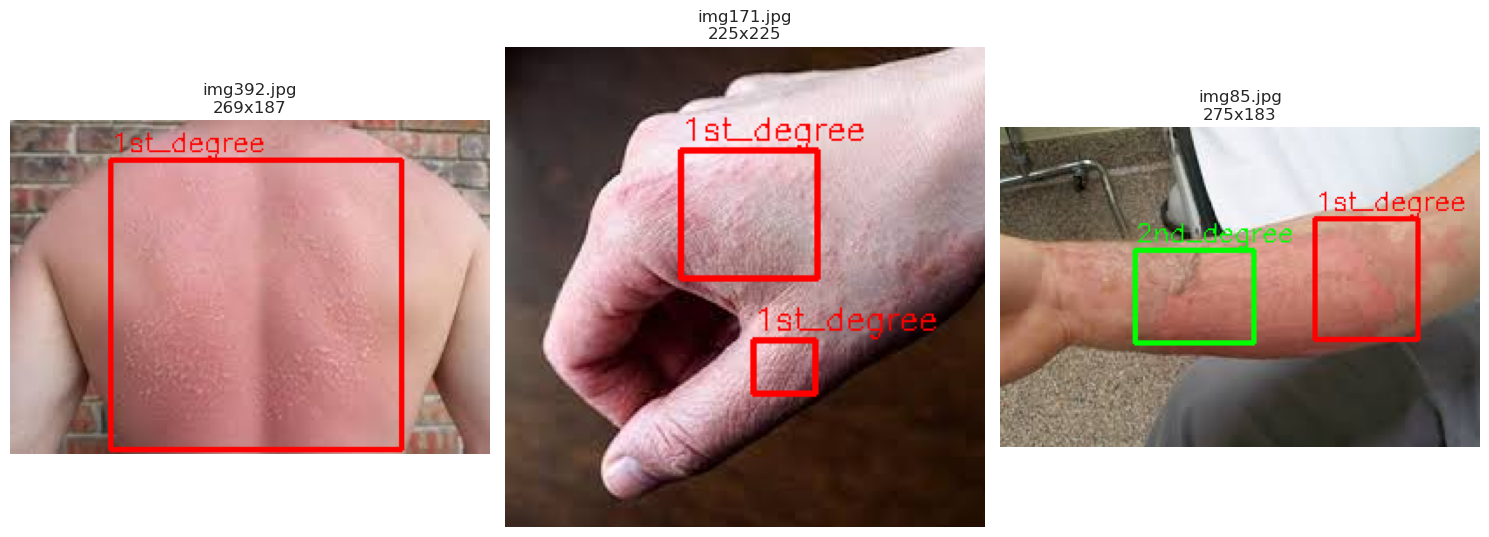

In [6]:
# ##  Visual Examination with Bounding Boxes

def plot_image_with_boxes(img_file, ax=None):
    """Plot image with YOLO bounding boxes"""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))

    img_path = os.path.join(dataset_path, img_file)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Get corresponding label file
    label_file = img_file.rsplit('.', 1)[0] + '.txt'
    if os.path.exists(os.path.join(dataset_path, label_file)):
        with open(os.path.join(dataset_path, label_file), 'r') as f:
            for line in f:
                class_id, x_center, y_center, width, height = map(float, line.strip().split())

                # Convert YOLO to pixel coordinates
                img_h, img_w = img.shape[:2]
                x_center *= img_w
                y_center *= img_h
                width *= img_w
                height *= img_h

                # Calculate rectangle coordinates
                x_min = int(x_center - width/2)
                y_min = int(y_center - height/2)
                x_max = int(x_center + width/2)
                y_max = int(y_center + height/2)

                # Draw rectangle
                color = [(255, 0, 0), (0, 255, 0), (0, 0, 255)][int(class_id)]
                cv2.rectangle(img, (x_min, y_min), (x_max, y_max), color, 2)
                cv2.putText(img, class_names[int(class_id)],
                            (x_min, y_min-5),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"{img_file}\n{img.shape[1]}x{img.shape[0]}")
    return ax

sample_images = random.sample(image_files, min(3, len(image_files)))

plt.figure(figsize=(15, 10))
for i, img_file in enumerate(sample_images, 1):
    ax = plt.subplot(1, 3, i)
    plot_image_with_boxes(img_file, ax)
plt.tight_layout()
plt.show()

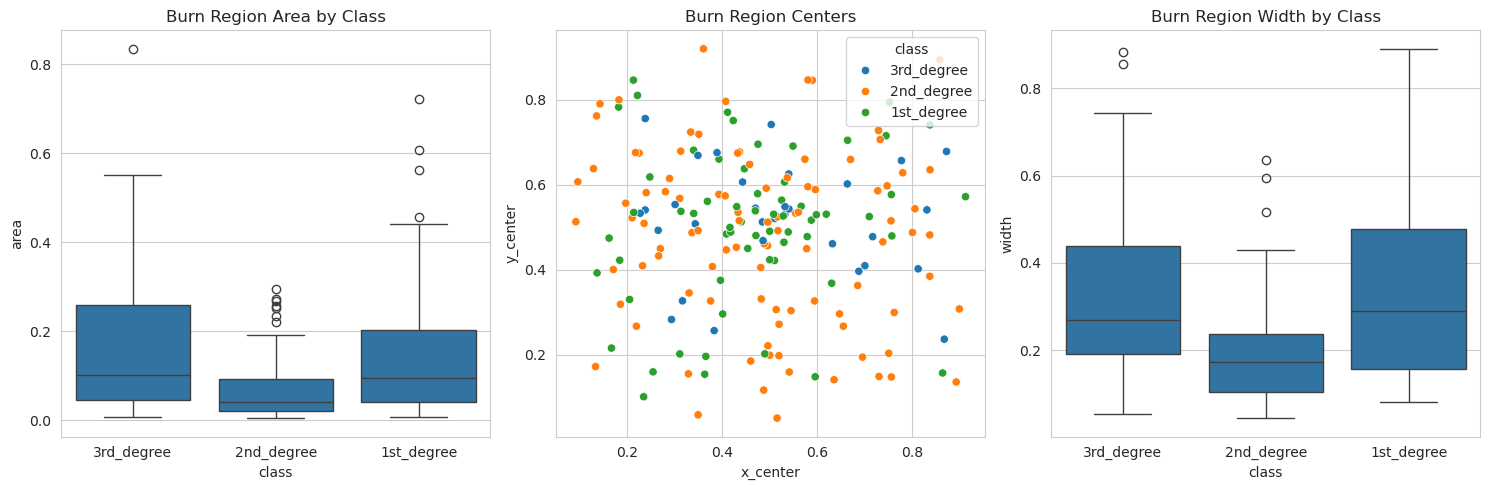

In [7]:
# ## Burn Region Analysis

def analyze_burn_regions(sample_size=5):
    """Analyze size and position of burn regions"""
    sample_labels = random.sample(label_files, min(sample_size, len(label_files)))
    burn_stats = []

    for label_file in sample_labels:
        try:
            with open(os.path.join(dataset_path, label_file), 'r') as f:
                for line in f:
                    class_id, x_center, y_center, width, height = map(float, line.strip().split())
                    burn_stats.append({
                        'class': class_names[int(class_id)],
                        'x_center': x_center,
                        'y_center': y_center,
                        'width': width,
                        'height': height,
                        'area': width * height
                    })
        except Exception as e:
            print(f"Error processing {label_file}: {e}")

    return pd.DataFrame(burn_stats)

burn_stats = analyze_burn_regions(100)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(x='class', y='area', data=burn_stats)
plt.title('Burn Region Area by Class')

plt.subplot(1, 3, 2)
sns.scatterplot(x='x_center', y='y_center', hue='class', data=burn_stats)
plt.title('Burn Region Centers')

plt.subplot(1, 3, 3)
sns.boxplot(x='class', y='width', data=burn_stats)
plt.title('Burn Region Width by Class')

plt.tight_layout()
plt.show()

02 DATA PREPROCESSING

In [8]:
import cv2
import numpy as np
from sklearn.model_selection import train_test_split

def preprocess_data(dataset_path, img_size=(224, 224)):
    """
    Preprocess skin burn dataset:
    1. Load images and labels
    2. Resize images
    3. Normalize pixel values
    4. Split into train/val/test sets
    """
    image_files = [f for f in os.listdir(dataset_path) if f.endswith(('.jpg', '.jpeg'))]
    label_files = [f.replace('.jpg', '.txt').replace('.jpeg', '.txt') for f in image_files]

    images = []
    labels = []

    for img_file, label_file in zip(image_files, label_files):
        # Load image
        img_path = os.path.join(dataset_path, img_file)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB
        img = cv2.resize(img, img_size)  # Resize
        img = img / 255.0  # Normalize

        # Load label
        label_path = os.path.join(dataset_path, label_file)
        with open(label_path, 'r') as f:
            class_id = int(f.readline().strip().split()[0])

        images.append(img)
        labels.append(class_id)

    # Convert to numpy arrays
    images = np.array(images)
    labels = np.array(labels)

    # Split data (60-20-20)
    X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42, stratify=labels)
    X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42, stratify=y_train)

    return X_train, X_val, X_test, y_train, y_val, y_test

finished:

✅ Organize into train/val/test folders	

✅ Check for corrupted or unreadable images	

✅ Visualize a few random images per class	

✅ Split dataset (if needed)	

✅ Set up transforms for resize, tensor, normalize

03 DATA AUGMENTATION

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

def create_augmenter():
    """Create image data augmenter"""
    return ImageDataGenerator(
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )

def visualize_augmentations(images, augmenter, n_samples=5):
    """Visualize augmented images"""
    fig, axes = plt.subplots(n_samples, 5, figsize=(15, 15))
    for i in range(n_samples):
        img = images[np.random.randint(0, len(images))]
        axes[i,0].imshow(img)
        axes[i,0].set_title('Original')
        axes[i,0].axis('off')

        for j in range(1, 5):
            augmented = augmenter.random_transform(img)
            axes[i,j].imshow(augmented)
            axes[i,j].set_title(f'Augmented {j}')
            axes[i,j].axis('off')

    plt.tight_layout()
    plt.show()

# Usage:
X_train, X_val, X_test, y_train, y_val, y_test = preprocess_data(dataset_path)
augmenter = create_augmenter()
visualize_augmentations(X_train, augmenter)

2025-07-17 14:28:26.120875: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-17 14:28:26.537795: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-17 14:28:26.665341: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752733706.930685   56907 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752733706.989501   56907 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1752733707.473756   56907 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

finished:

train_loader applies real-time augmentations	✅

val_loader uses clean validation data	✅

Augmented images shown in a plot	✅

04 DATA PPREPARATION

In [10]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

def prepare_data(X_train, X_val, X_test, y_train, y_val, y_test, num_classes=3):
    """
    Prepare data for hybrid model:
    1. Convert labels to categorical
    2. Normalize images
    3. Prepare YOLO annotation data
    """
    # Convert labels to one-hot encoding
    y_train = to_categorical(y_train, num_classes=num_classes)
    y_val = to_categorical(y_val, num_classes=num_classes)
    y_test = to_categorical(y_test, num_classes=num_classes)

    # Normalize images to [-1, 1] range (better for pretrained models)
    X_train = (X_train * 2) - 1
    X_val = (X_val * 2) - 1
    X_test = (X_test * 2) - 1

    return X_train, X_val, X_test, y_train, y_val, y_test

05 CNN MODEL IMPLEMENTATION

In [11]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Model

def build_cnn_backbone(input_shape=(224, 224, 3)):
    """Build CNN feature extractor for burn pattern recognition"""
    inputs = tf.keras.Input(shape=input_shape)

    # Initial convolutional blocks
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = MaxPooling2D((2, 2))(x)

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2))(x)

    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2))(x)

    # Deeper layers for high-level features
    x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2))(x)

    x = Conv2D(512, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2))(x)

    return Model(inputs, x, name='CNN_Backbone')

06 TRANSFORMER MODULE IMPLEMENTATION

In [12]:
from tensorflow.keras.layers import Input, Dense, MultiHeadAttention, LayerNormalization
from tensorflow.keras.models import Model

class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super(TransformerBlock, self).__init__()
        self.att = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            Dense(ff_dim, activation="relu"),
            Dense(embed_dim),
        ])
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = tf.keras.layers.Dropout(rate)
        self.dropout2 = tf.keras.layers.Dropout(rate)

    def call(self, inputs, training):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

def build_transformer_module(max_length=100, embed_dim=64, num_heads=4, ff_dim=256):
    """Process YOLO annotation data with transformer"""
    inputs = Input(shape=(max_length, 5))  # (x, y, w, h, class)

    # Positional embedding
    positions = tf.range(start=0, limit=max_length, delta=1)
    position_embedding = tf.keras.layers.Embedding(
        input_dim=max_length, output_dim=embed_dim)(positions)

    # Annotation embedding
    annotation_embedding = Dense(embed_dim)(inputs)
    x = annotation_embedding + position_embedding

    # Transformer blocks
    x = TransformerBlock(embed_dim, num_heads, ff_dim)(x)
    x = TransformerBlock(embed_dim, num_heads, ff_dim)(x)

    # Global average pooling
    x = tf.keras.layers.GlobalAveragePooling1D()(x)

    return Model(inputs, x, name='Transformer_Module')

07 MULTI MODAL FUSION

In [13]:
from tensorflow.keras.layers import Concatenate, GlobalAveragePooling2D

def build_multimodal_fusion(cnn_model, transformer_model, num_classes=3):
    """Combine CNN and Transformer features"""
    # Image input and features
    img_input = cnn_model.input
    cnn_features = cnn_model.output
    cnn_pooled = GlobalAveragePooling2D()(cnn_features)

    # Annotation input and features
    anno_input = transformer_model.input
    anno_features = transformer_model.output

    # Concatenate features
    combined = Concatenate()([cnn_pooled, anno_features])

    # Classification head
    x = Dense(256, activation='relu')(combined)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    return Model(inputs=[img_input, anno_input], outputs=outputs, name='Multimodal_Fusion')

08 HYBRID CNN TRANSFORMER MODEL

In [14]:
def build_hybrid_model(input_shape=(224, 224, 3), max_length=100, num_classes=3):
    """Build complete hybrid model"""
    # Build components
    cnn_backbone = build_cnn_backbone(input_shape)
    transformer_module = build_transformer_module(max_length)

    # Combine with fusion
    hybrid_model = build_multimodal_fusion(cnn_backbone, transformer_module, num_classes)

    # Compile model
    hybrid_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return hybrid_model

09 DECISION SUPPORT SYSTEM

In [15]:
class BurnSeverityDSS:
    def __init__(self, model_path, img_size=(224, 224), max_annotations=100):
        self.model = tf.keras.models.load_model(model_path)
        self.img_size = img_size
        self.max_annotations = max_annotations

    def preprocess_image(self, img_path):
        """Preprocess single image"""
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, self.img_size)
        img = (img / 127.5) - 1.0  # Normalize to [-1, 1]
        return np.expand_dims(img, axis=0)

    def preprocess_annotations(self, annotation_path):
        """Preprocess YOLO annotations"""
        with open(annotation_path, 'r') as f:
            lines = f.readlines()

        annotations = []
        for line in lines[:self.max_annotations]:
            parts = list(map(float, line.strip().split()))
            annotations.append(parts)

        # Pad if fewer than max_length
        while len(annotations) < self.max_annotations:
            annotations.append([0]*5)

        return np.array([annotations])

    def predict(self, img_path, annotation_path):
        """Make prediction with confidence scores"""
        img = self.preprocess_image(img_path)
        annotations = self.preprocess_annotations(annotation_path)

        pred_probs = self.model.predict([img, annotations])[0]
        pred_class = np.argmax(pred_probs)
        confidence = np.max(pred_probs)

        return {
            'class': int(pred_class),
            'confidence': float(confidence),
            'probabilities': {
                '1st_degree': float(pred_probs[0]),
                '2nd_degree': float(pred_probs[1]),
                '3rd_degree': float(pred_probs[2])
            }
        }

10 MODEL OPTIMIZATION

11 DEPLOYMENT PREPARATION